In [2]:
%pip install numpy seaborn pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import calendar
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [4]:
df = pd.read_csv("births.csv")
# print(df.head(),"\n")
# print(df.shape)
# print(f"Maximum number of Births in a month {max(df.births)}") #Need to fix per month Records
# print(f"Minimum number of Births in a month {min(df.births)}")
# print(f"Minimum Day in a month {min(df.day)}") #Correct
print(f"Maximum Day in a month {max(df.day)}") #wrong
print(df.gender.unique()) #Correct 
print(df.month.unique())

print(df.info())
print(f"\nList of Not Assigned in DataFrame:\n{df.isna().sum()}")


Maximum Day in a month 99.0
<StringArray>
['F', 'M']
Length: 2, dtype: str
[ 1  2  3  4  5  6  7  8  9 10 11 12]
<class 'pandas.DataFrame'>
RangeIndex: 15547 entries, 0 to 15546
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    15547 non-null  int64  
 1   month   15547 non-null  int64  
 2   day     15067 non-null  float64
 3   gender  15547 non-null  str    
 4   births  15547 non-null  int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 607.4 KB
None

List of Not Assigned in DataFrame:
year        0
month       0
day       480
gender      0
births      0
dtype: int64


Number of Days in a month is maxed at 99 which cant be possible and all months at that 
Lets Remove those fields in data Cleaning before analysis  because that will skew the data
Days are not assigned after few years and data is calculated in months so that needs collection as well. beacuse thats after 1989 to 2008

In [5]:
# df["month"].value_counts().sort_index()
daily = df[df["day"].notna()].copy()
daily["day"] = daily["day"].astype(int)  #float to int 

daily["max_day"] = daily.apply(
    lambda r: calendar.monthrange(int(r["year"]), int(r["month"]))[1], axis=1)


daily["status"] = "valid" #setting status column as valid and removing later on if value is invalid
daily.loc[daily["day"] == 99, "status"] = "sentinel_99"

# A day that is bigger than the month's real max day is impossible (e.g. Feb 30)
daily.loc[(daily["day"] != 99) & (daily["day"] > daily["max_day"]), "status"] = "impossible"

# A day below 1 is also impossible (there is no day 0)
daily.loc[daily["day"] < 1, "status"] = "impossible"

# .value_counts() now shows how many rows are valid / sentinel / impossible
print(daily["status"].value_counts())

# Split the rows into three groups so we can handle each one differently
sentinel   = daily[daily["status"] == "sentinel_99"]
impossible = daily[daily["status"] == "impossible"]
valid      = daily[daily["status"] == "valid"]

# Show a few example impossible dates (these are data errors)
print("Example impossible dates (these are wrong and must be dropped):")
print(impossible[["year", "month", "day", "gender", "births"]].head(10))

# Show the leap-year Feb 29 rows (these are REAL and must be kept)
feb29 = valid[(valid["month"] == 2) & (valid["day"] == 29)]
print("Leap-year Feb 29 rows KEPT as valid:", len(feb29))
print(feb29[["year", "month", "day", "gender", "births"]].to_string(index=False))


status
valid          14610
sentinel_99      350
impossible       107
Name: count, dtype: int64
Example impossible dates (these are wrong and must be dropped):
     year  month  day gender  births
120  1969      2   29      F      50
121  1969      2   29      M      16
122  1969      2   30      F      24
123  1969      2   30      M      28
124  1969      2   31      F      24
125  1969      2   31      M      20
252  1969      4   31      F      28
253  1969      4   31      M      24
380  1969      6   31      F      20
381  1969      6   31      M      40
Leap-year Feb 29 rows KEPT as valid: 10
 year  month  day gender  births
 1972      2   29      F    4663
 1972      2   29      M    4919
 1976      2   29      F    3681
 1976      2   29      M    3878
 1980      2   29      F    4646
 1980      2   29      M    4969
 1984      2   29      F    4773
 1984      2   29      M    4907
 1988      2   29      F    4859
 1988      2   29      M    4939


In [6]:
# ---- clean ----

# impossible.index = the row positions of the impossible dates 
# df.index.isin(...) = "is this row position in that list?" -> True/False
# ~ = "NOT" -> keep everything that is NOT an impossible date
before = len(df)
df = df[~df.index.isin(impossible.index)]
print("Impossible-date rows dropped:", before - len(df))
#same as impossible
before = len(df)
df = df[~df.index.isin(sentinel.index)]
print("Sentinel (day=99) rows dropped:", before - len(df))

# Make sure births are numbers
df["births"] = pd.to_numeric(df["births"], errors="coerce")

# More Readability for Gender
df["gender"] = df["gender"].str.strip().str.upper()

# Remove exact duplicate rows
df = df.drop_duplicates()
print("Rows left after cleaning:", len(df))


Impossible-date rows dropped: 107
Sentinel (day=99) rows dropped: 350
Rows left after cleaning: 15090


In [7]:
valid_rows = df[df["day"].notna()].copy() # Collecting so that we can sum for each month soonly those days are selected that has some data not those on monthly basis 
monthly = df[df["day"].isna()].copy() #Collected as monthly based collection 

# groupby(["year","month","gender"]) = "group rows that share year+month+gender"
# This turns daily rows into monthly rows total because data is of 40 years
daily_monthly = valid_rows.groupby(["year", "month", "gender"], as_index=False)["births"].sum()

# Now combine the daily-collected years (which is now monthly) with the already-monthly-collected years
clean = pd.concat([daily_monthly, monthly], ignore_index=True)

# Sort the table neatly by year, then month, then gender
clean = clean.drop(columns=["day"], errors="ignore")
clean = clean.sort_values(["year", "month", "gender"]).reset_index(drop=True)

# 40 years x 12 months x 2 genders = 960 rows. Every row now means the same thing!
clean.to_csv("births_cleaned_withmonthsOnly.csv", index=False)
print("Clean table shape:", clean.shape)
print(clean.head(8))


Clean table shape: (960, 4)
   year  month gender  births
0  1969      1      F  143704
1  1969      1      M  150172
2  1969      2      F  132218
3  1969      2      M  138316
4  1969      3      F  144020
5  1969      3      M  152416
6  1969      4      F  137182
7  1969      4      M  145288


In [8]:
clean["month"].value_counts().sort_index()

month
1     80
2     80
3     80
4     80
5     80
6     80
7     80
8     80
9     80
10    80
11    80
12    80
Name: count, dtype: int64

Above clean["month"].value_counts() shows all months with number of times they are repeated in all of the clean dataFrame, every value is 80 because male and female birth records are needed seperately. 40years and each month doubled so 80 times each month



In [9]:
# Total births in Total
print("Total births 1969-2008:", int(clean["births"].sum()))

# Which month has the most/least births on average? (seasonality)
season = clean.groupby("month", as_index=False)["births"].mean()
print("Peak month (avg):", int(season.loc[season["births"].idxmax(), "month"]))
print("Least month (avg):",int(season.loc[season["births"].idxmin(),"month"]))
# Yearly totals per gender (for the scatter chart later)
yearly = clean.groupby(["year", "gender"], as_index=False)["births"].sum()
piv_y  = yearly.pivot(index="year", columns="gender", values="births").reset_index()
print("Correlation M vs F:", round(piv_y["M"].corr(piv_y["F"]), 5))


Total births 1969-2008: 151766945
Peak month (avg): 8
Least month (avg): 2
Correlation M vs F: 0.99987


In [10]:
highest_gender_year = yearly.loc[yearly.groupby("gender")["births"].idxmax()]
total_per_year = yearly.groupby("year", as_index=False)["births"].sum()

# Get the row with the maximum births
highest_year = total_per_year.loc[total_per_year["births"].idxmax()]

print(highest_year)
print(highest_gender_year)

year         2007
births    4324008
Name: 38, dtype: int64
    year gender   births
76  2007      F  2111890
77  2007      M  2212118


In [11]:
print(f"Maximum number of Births in a month {max(clean.births)}") 
print(f"Minimum number of Births in a month {min(clean.births)}")
# Group by year and month, then compute absolute difference
gap_df = (
    clean.groupby(["year", "month"])
    .apply(lambda g: abs(g.loc[g["gender"] == "M", "births"].values[0] - 
                        g.loc[g["gender"] == "F", "births"].values[0]))
    .reset_index(name="gap")
)

# Find the row with the smallest gap
closest = gap_df.loc[gap_df["gap"].idxmin()]
biggest= gap_df.loc[gap_df["gap"].idxmax()]
print(f"Closest Gap between F and F was :{closest.gap}")
print(f"Closest Gap between F and F was from:{closest.year} Month: {closest.month}")
print(f"Biggest Gap between M and F was :{biggest.gap}")
print(f"Biggest Gap between M and F was from:{biggest.year} Month {biggest.month}")
print(clean.gender.unique()) 
print(clean.month.unique())

print(clean.info())
print(f"\nList of Not Assigned in DataFrame:\n{clean.isna().sum()}")


Maximum number of Births in a month 199622
Minimum number of Births in a month 115851
Closest Gap between F and F was :5177
Closest Gap between F and F was from:1973 Month: 9
Biggest Gap between M and F was :10694
Biggest Gap between M and F was from:1970 Month 7
<StringArray>
['F', 'M']
Length: 2, dtype: str
[ 1  2  3  4  5  6  7  8  9 10 11 12]
<class 'pandas.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   year    960 non-null    int64
 1   month   960 non-null    int64
 2   gender  960 non-null    str  
 3   births  960 non-null    int64
dtypes: int64(3), str(1)
memory usage: 30.1 KB
None

List of Not Assigned in DataFrame:
year      0
month     0
gender    0
births    0
dtype: int64


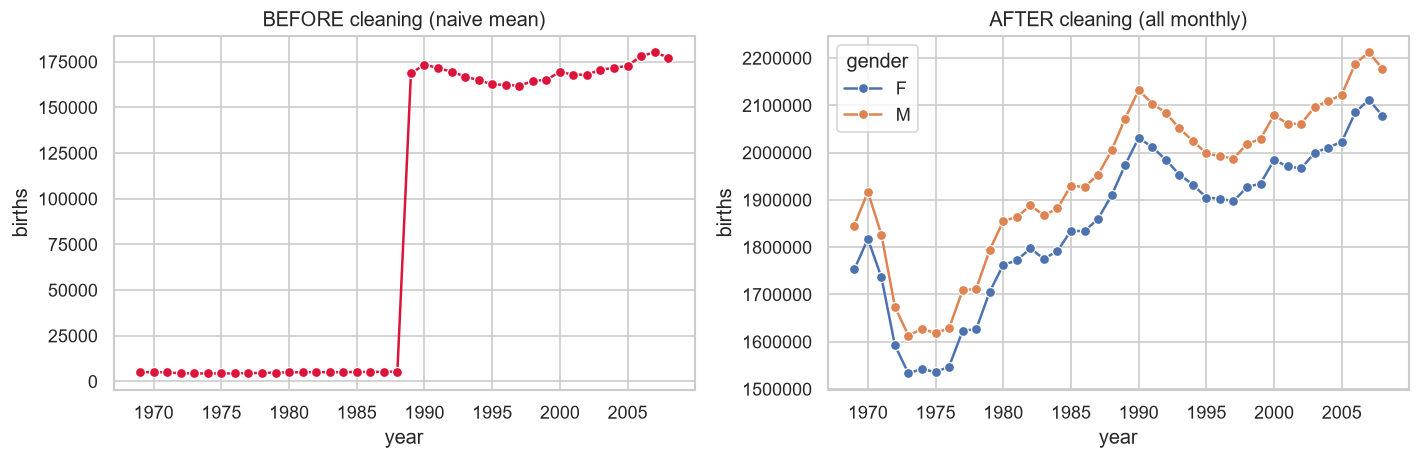

In [12]:
# ---- CHART 0 : before vs after ----

# The WRONG way: group by year and take the mean of whatever rows exist.
# Years 1969-88 have daily rows (~4,700) so the mean is small.
# Years 1989-08 have monthly rows (~170,000) so the mean is huge.
# -> a fake cliff in the middle of the chart!
naive = df.groupby("year")["births"].mean().reset_index()

# Make a figure with 1 row and 2 side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: the naive (wrong) yearly mean
sns.lineplot(data=naive, x="year", y="births", color="crimson", marker="o", ax=axes[0])
axes[0].set_title("BEFORE cleaning (naive mean)")

# Right plot: the cleaned yearly totals
sns.lineplot(data=yearly, x="year", y="births", hue="gender", marker="o", ax=axes[1])
axes[1].set_title("AFTER cleaning (all monthly)")
plt.ticklabel_format(style='plain', axis='y')
# make sure nothing overlaps, then show the figure
plt.tight_layout()
plt.show()


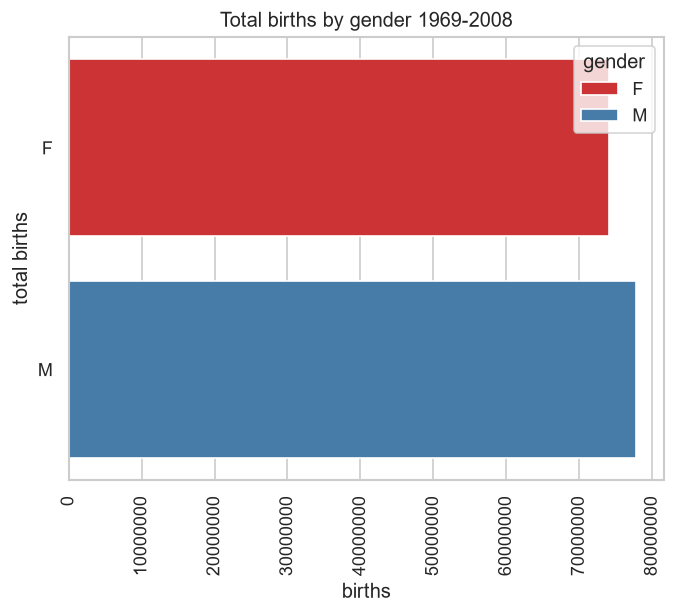

In [13]:
# ---- CHART 1 : bar chart ----

# Add up all births for each gender
totals = clean.groupby("gender", as_index=False)["births"].sum()

# sns.barplot draws one bar per category. hue="gender" colours them.
# legend=False hides the colour-key (we only have 2 bars, no need for it).
sns.barplot(data=totals, x="births", y="gender", hue="gender", palette="Set1", legend=True)

# Give the chart a title and a label for the vertical axis
plt.title("Total births by gender 1969-2008")
plt.ylabel("total births")
plt.ticklabel_format(style="plain",axis="x")
plt.xticks(rotation=90,ha="center")
# .show() actually displays the chart
plt.show()


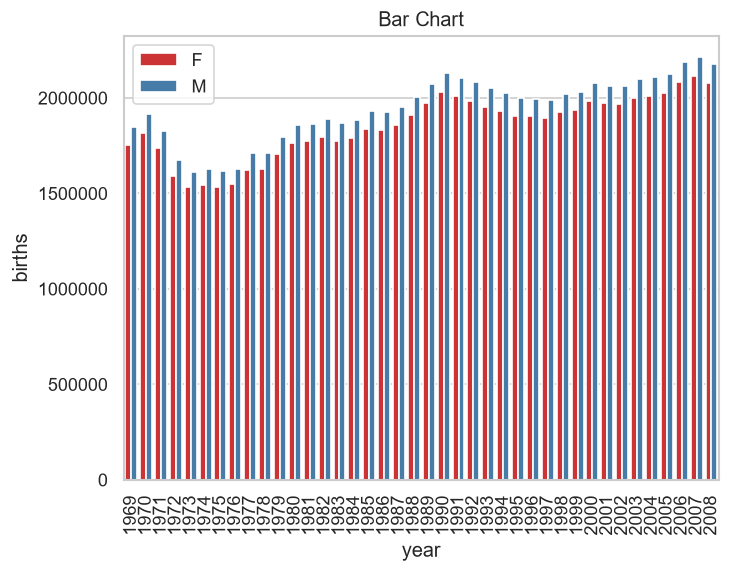

In [14]:
sns.barplot(data=clean, x='year', y='births', hue='gender', palette="Set1",estimator="sum",errorbar=None)
plt.title("Bar Chart")

plt.xticks(rotation=90, ha='center')  # 90-degree tilt aligned to tick mark
plt.ticklabel_format(style='plain', axis='y')  #for showing values in numbers not 1E6 which means 10^6
plt.legend(loc="upper left")
plt.show()

Data is Clean but its in different months of year and we plotted years so it will take mean of months and plot with it so we have to further enhance it with groupby or add estimator( Like above).
First With estimator="sum" and errorbar=None

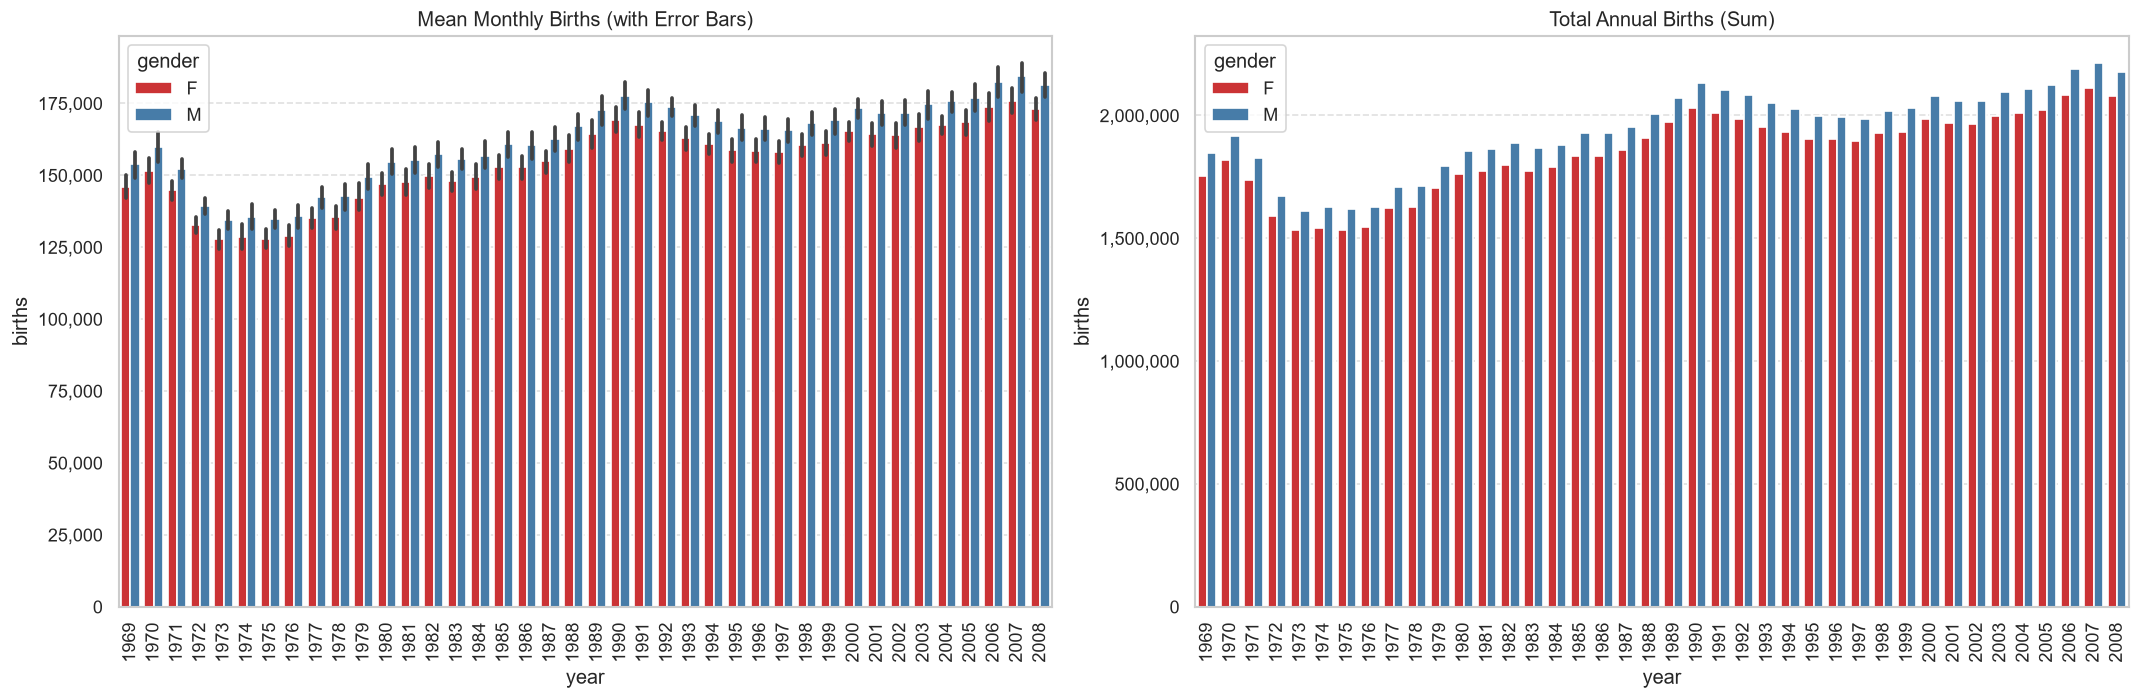

In [15]:
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- LEFT SUBPLOT: Mean Monthly Births ---
sns.barplot(
    data=clean, x="year", y="births", hue="gender", palette="Set1", ax=axes[0]
)
axes[0].set_title("Mean Monthly Births (with Error Bars)", fontsize=12)
axes[0].tick_params(axis="x", rotation=90)  # Rotates ticks on left plot
axes[0].ticklabel_format(style="plain", axis="y")  # Removes scientific notation
axes[0].yaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:,.0f}")
)  # Adds commas
axes[0].set_axisbelow(True)  # Places grid lines behind bars
axes[0].grid(
    True, linestyle="--", alpha=0.6, axis="y"
)
# --- RIGHT SUBPLOT: Total Annual Births ---
totals = clean.groupby(["year", "gender"], as_index=False)["births"].sum()
sns.barplot(
    data=totals, x="year", y="births", hue="gender", palette="Set1", ax=axes[1]
)
axes[1].set_title("Total Annual Births (Sum)", fontsize=12)
axes[1].tick_params(axis="x", rotation=90)  # Rotates ticks on right plot
axes[1].ticklabel_format(style="plain", axis="y")  # Removes scientific notation
axes[1].yaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:,.0f}")
)  # Adds commas
axes[1].set_axisbelow(True)  # Places grid lines behind bars
axes[1].grid(
    True, linestyle="--", alpha=0.6, axis="y"
)
# Prevent subplot title and axis label collisions
plt.tight_layout()
plt.show()

We used yearly dataframe that we created earlier for comparison between bad data and cleaned data

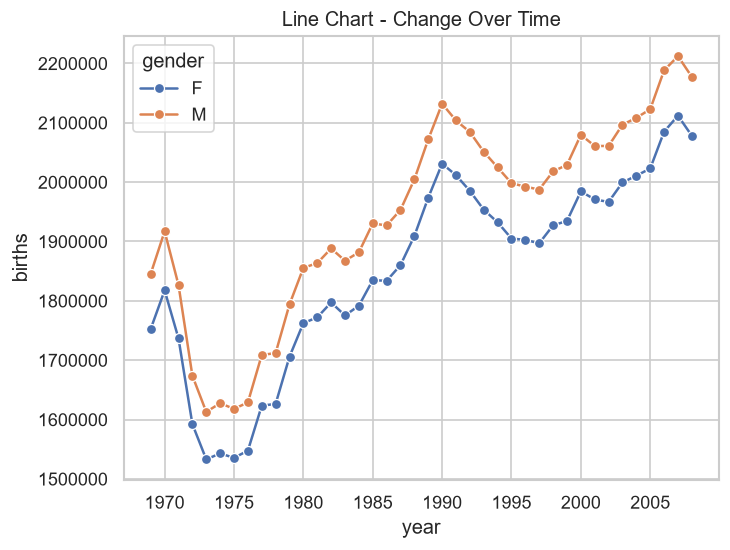

In [16]:
sns.lineplot(data=yearly, x='year',y='births', hue='gender', marker='o') #We made a dataset for yearly records 
plt.title("Line Chart - Change Over Time")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

Lets share the Comparison with mean values in line chart and sum

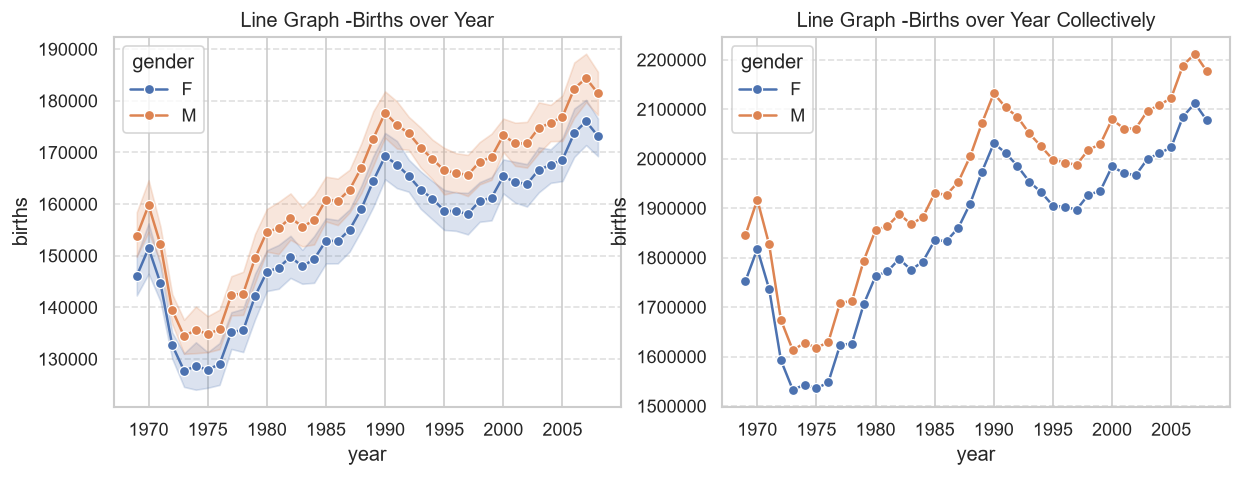

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#figure 1 with estimator="mean" by default with error bar
sns.lineplot(data=clean, x='year',y='births', hue='gender', marker='o',ax=axes[0])
axes[0].set_axisbelow(True)
axes[0].grid(
    True, linestyle="--", alpha=0.6, axis="y"
)
axes[0].set_title("Line Graph -Births over Year")
#figure 2 with estimator="sum"
sns.lineplot(data=clean, x='year',y='births', hue='gender',errorbar=None,estimator="sum", marker='o',ax=axes[1]) 
axes[1].set_axisbelow(True)
axes[1].grid(
    True, linestyle="--", alpha=0.6, axis="y"
)
axes[1].set_title("Line Graph -Births over Year Collectively")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

As you can see in above figures no with error bars and estimator=mean(by default) shows births at maximum below 190k whereas on the right it shows correct numbers without mean but actual values from each year sum and values reach just below 2.2m

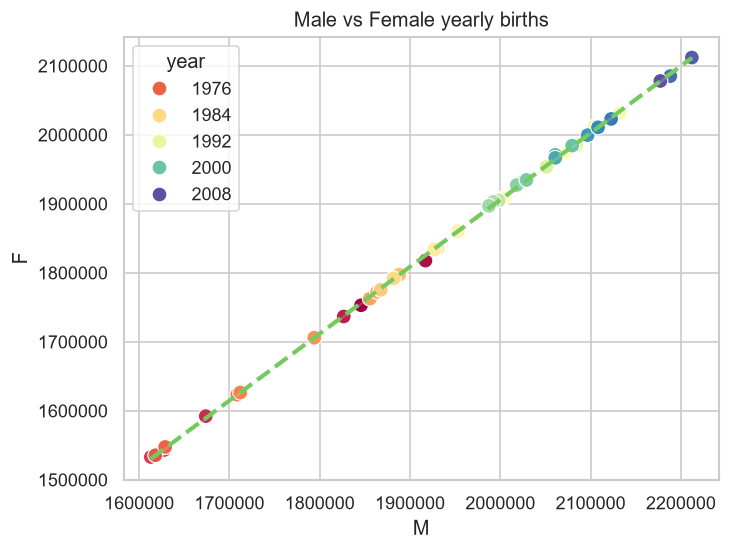

In [18]:
sns.scatterplot(data=piv_y, x="M", y="F", s=80,hue="year",palette="Spectral")   # s=80 = bigger dots

# Add a straight "trend line" through the dots (grey) to see the relationship
sns.regplot(data=piv_y, x="M", y="F", scatter=False,scatter_kws={"color": "#4361ee", "s": 70, "alpha": 0.7},line_kws={
        "color": "#74CA5F",
        "linewidth": 2.5,
        "linestyle": "--",
    })
plt.title("Male vs Female yearly births")
plt.ticklabel_format(style="plain",axis="x")
plt.ticklabel_format(style="plain",axis="y")
plt.show()


Male and Female births accross different years over the span of 40 years show the relation that growth of both is relatively close and almost same with about 13 difference over every 10000 in favor of Males

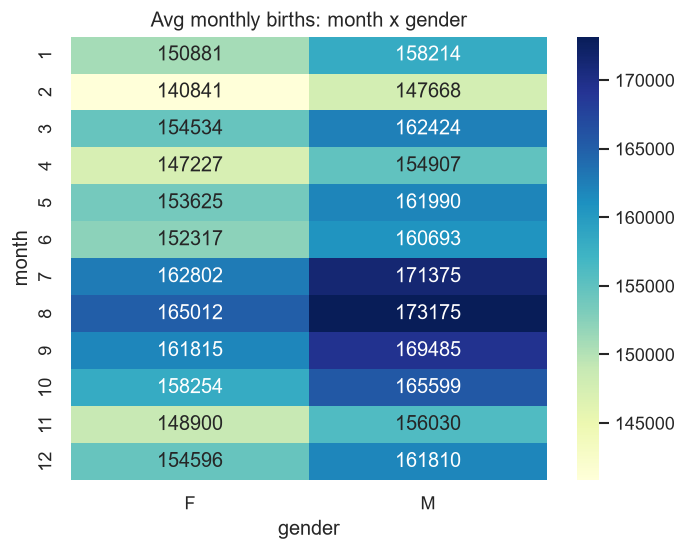

In [19]:
hm = clean.groupby(["month", "gender"], as_index=False)["births"].mean()

# pivot reshapes it into a grid: rows = month, columns = gender
hm = hm.pivot(index="month", columns="gender", values="births")

# sns.heatmap colours the grid. annot=True prints the number inside each cell.
sns.heatmap(hm, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("Avg monthly births: month x gender")
plt.show()

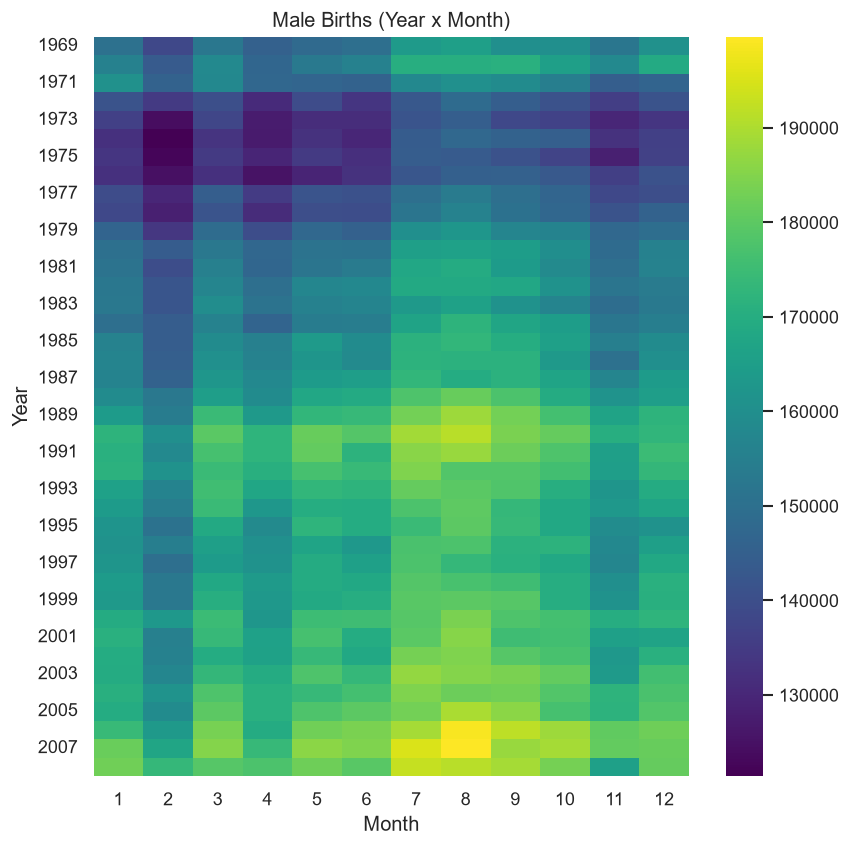

In [20]:
#Filter for one gender and pivot: 40 rows (Year) x 12 columns (Month)
hm2_piv = clean[clean["gender"] == "M"].pivot(
    index="year", columns="month", values="births"
)

#Plot (annot=False so text isn't overcrowded across 480 cells)
plt.figure(figsize=(8, 8))
sns.heatmap(hm2_piv, annot=False, cmap="viridis")

plt.title("Male Births (Year x Month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

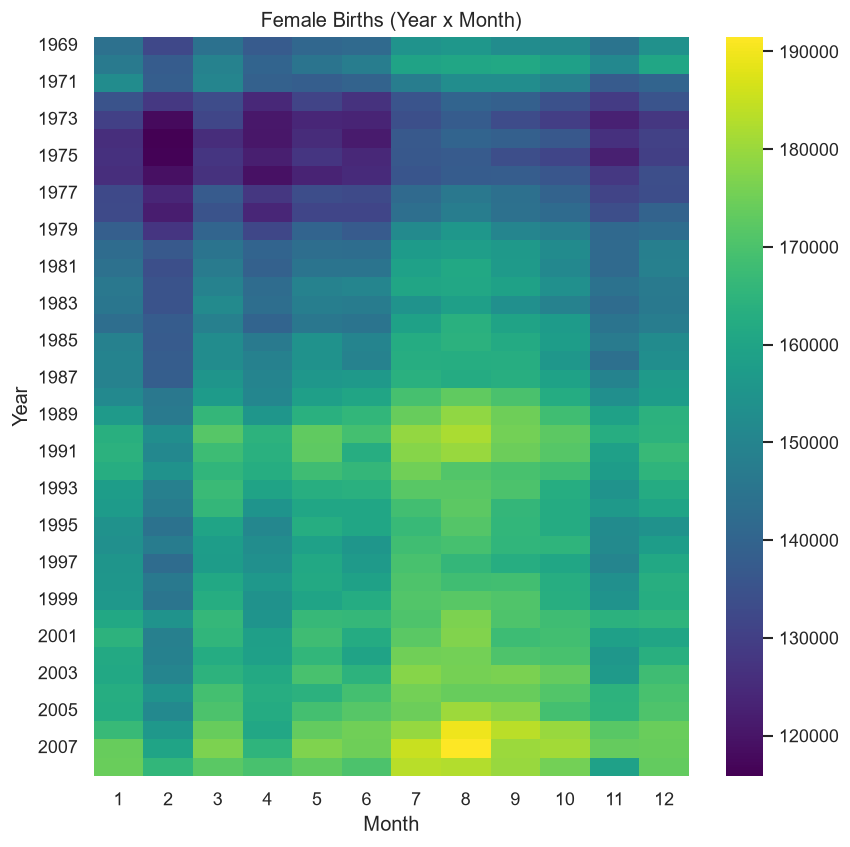

In [21]:
#Filter for one gender and pivot: 40 rows (Year) x 12 columns (Month)
hm2_piv = clean[clean["gender"] == "F"].pivot(
    index="year", columns="month", values="births"
)

# 2. Plot (annot=False so text isn't overcrowded across 480 cells)
plt.figure(figsize=(8, 8))
sns.heatmap(hm2_piv, annot=False, cmap="viridis")

plt.title("Female Births (Year x Month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

Exact Birth records also prove that over the years August and July had been Best Months for Births for Males and females with high number of births especially after 1989. 

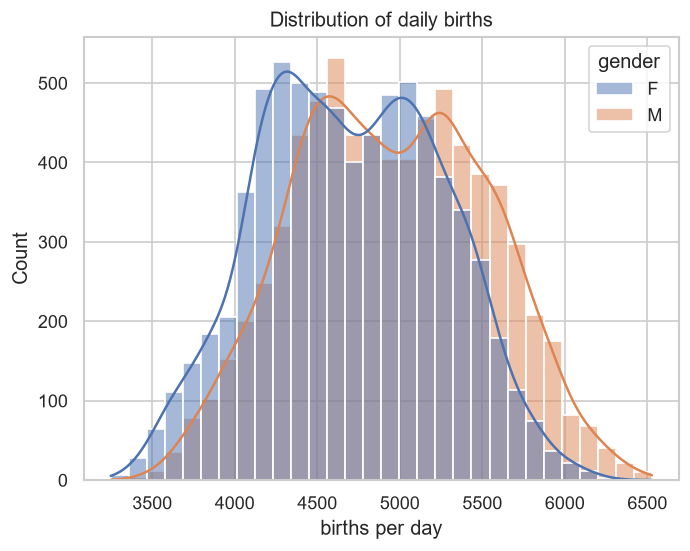

In [ ]:
sns.histplot(data=valid, x="births",hue="gender", bins=30, kde=True, color="steelblue")
plt.title("Distribution of daily births")
plt.xlabel("births per day")
plt.show()


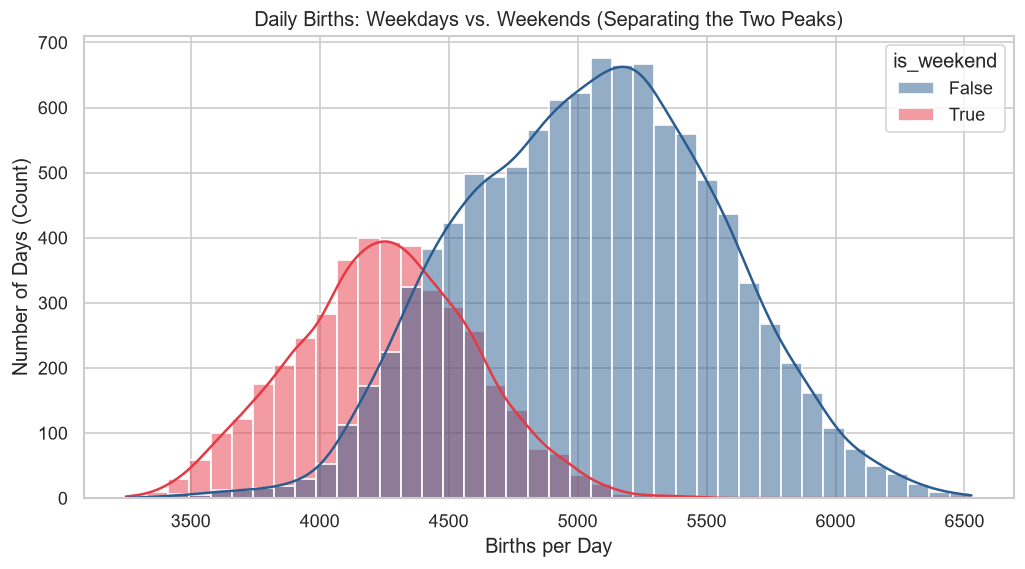

In [23]:

# 1. Feature Engineering: Extract the day of the week
valid["dt"] = pd.to_datetime(
    valid[["year", "month", "day"]]
)  # combine into datetime
valid["is_weekend"] = valid["dt"].dt.dayofweek >= 5  # 5 = Sat, 6 = Sun

# 2. Plot two distributions overlaid on top of each other
plt.figure(figsize=(10, 5))
sns.histplot(
    data=valid,
    x="births",
    hue="is_weekend",
    bins=40,
    kde=True,
    palette={False: "#2b5c8f", True: "#e63946"},
)

plt.title("Daily Births: Weekdays vs. Weekends (Separating the Two Peaks)")
plt.xlabel("Births per Day")
plt.ylabel("Number of Days (Count)")
plt.show()

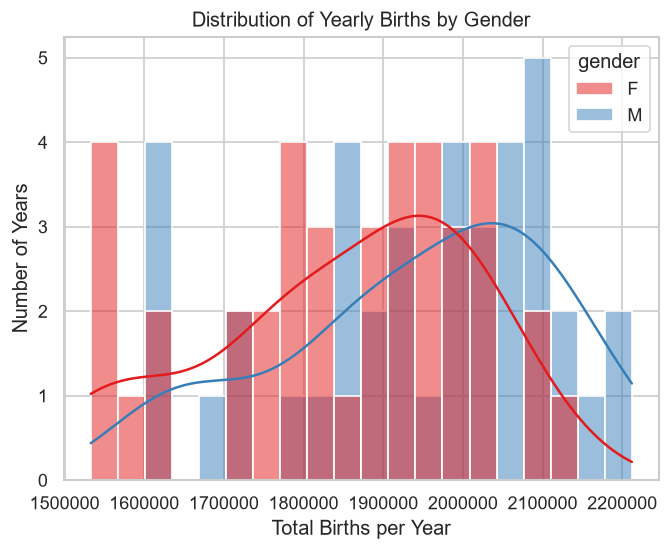

In [36]:
sns.histplot(
    data=yearly,
    x="births",
    hue="gender",
    bins=20,  # Lower bins recommended since yearly datasets have fewer total rows
    kde=True,
    palette="Set1",
)

plt.title("Distribution of Yearly Births by Gender")
plt.xlabel("Total Births per Year")
plt.ylabel("Number of Years")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

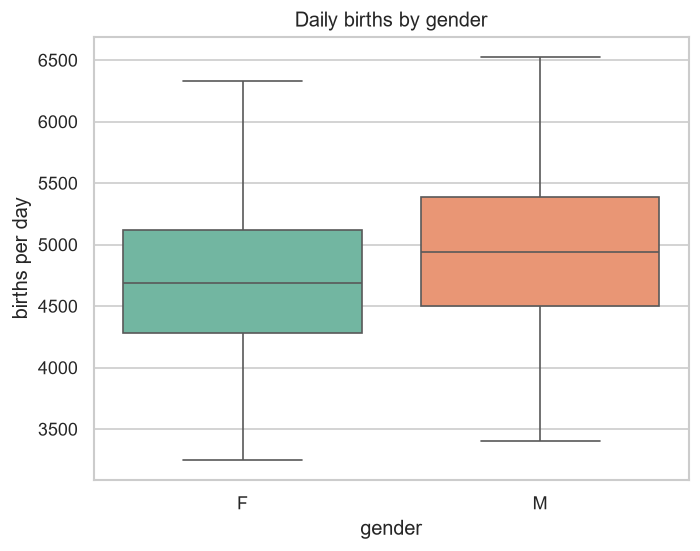

In [37]:
sns.boxplot(data=valid, x="gender", y="births", hue="gender", palette="Set2", legend=False)

plt.title("Daily births by gender")
plt.ylabel("births per day")
plt.show()

Box plot also confirms the middle 50% of births of both F and Male show Male births on higher levels per day till 1988, Next Box Plot will have yearly.

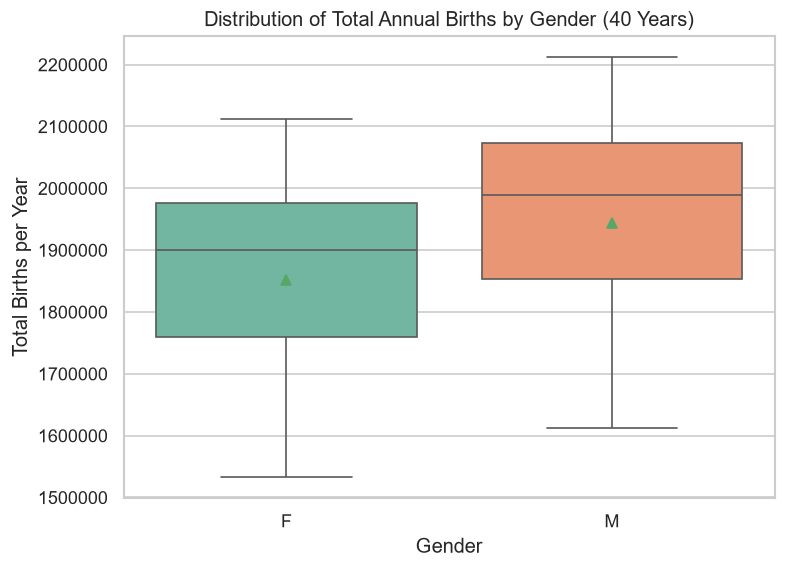

In [40]:
plt.figure(figsize=(7, 5))

# Plot showing median and middle 50% (IQR)
sns.boxplot(
    data=yearly,
    x="gender",
    y="births",
    hue="gender",
    palette="Set2",
    legend=False,
    showmeans=True,  # Adds a point marker for the mean alongside the median
)

plt.title("Distribution of Total Annual Births by Gender (40 Years)")
plt.xlabel("Gender")
plt.ylabel("Total Births per Year")  # Updated from 'births per day'
plt.ticklabel_format(axis="y", style="plain")

plt.show()

Box plot over the 40 years of births with 50% middle values and mean show that Male births per year median is also higher than box plotted for Female with IQR top range(75% Perrcentile)
also Male Side Mean is higher than Female Birth per year Median


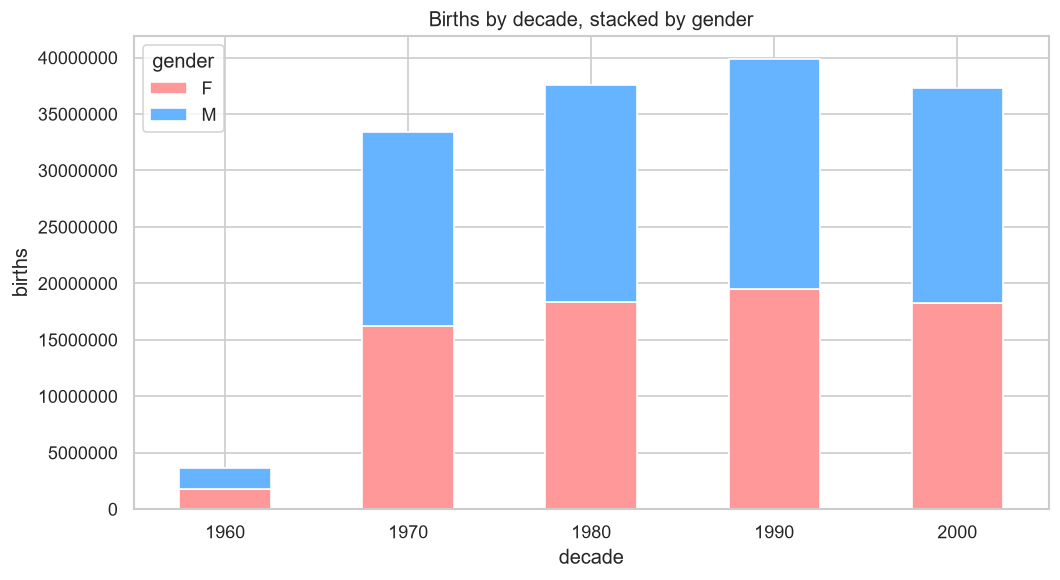

In [51]:
clean["decade"] = (clean["year"] // 10) * 10

# Total births per decade, per gender
dec = clean.groupby(["decade", "gender"], as_index=False)["births"].sum()
dec_piv = dec.pivot(index="decade", columns="gender", values="births")

# kind="bar" = bar chart, stacked=True = pile the genders on top of each other
dec_piv.plot(kind="bar", stacked=True, color=["#ff9999", "#66b3ff"], figsize=(9, 5))

plt.title("Births by decade, stacked by gender")
plt.ylabel("births")
plt.xticks(rotation=0)  # keep the decade labels horizontal
plt.ticklabel_format(axis="y",style="plain")
plt.tight_layout()
plt.show()


from 1960s we only have 1969 and from 2000s, we got till 2008 nothing after that but its birth records are relatively closer to 1990s

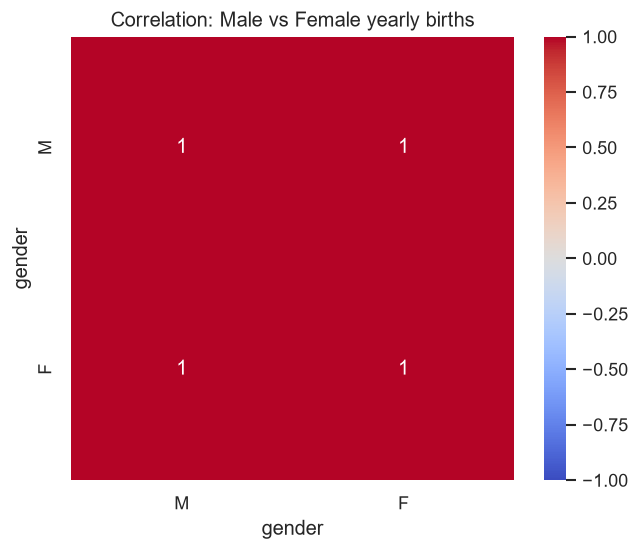

In [52]:
corr = piv_y[["M", "F"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation: Male vs Female yearly births")
plt.show()

Values of both genders go almost high together correlation shows the relation 